In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def compute_corner_error(H_gt, H_est, w, h):
    """Berechnet den mittleren quadratischen Fehler (RMSE) der 4 Bildecken."""
    if H_est is None:
        return np.nan

    # Definiere die 4 Ecken des Referenzbildes (Bild 1)
    corners = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)

    # Transformiere die Ecken mit Ground-Truth und geschätzter Matrix
    corners_gt = cv2.perspectiveTransform(corners, H_gt)
    corners_est = cv2.perspectiveTransform(corners, H_est)

    # RMSE berechnen
    return np.sqrt(np.mean((corners_gt - corners_est) ** 2))

In [3]:
def evaluate_hpatches_sequence(sequence_folder, plot_pair=True, target_image_to_plot=4, v_sequence="v_london"):
    """Evaluisiert eine komplette HPatches-Sequenz (Bild 1 gegen Bilder 2-6)."""
    # 1. Referenzbild 1 laden
    img1_path = os.path.join(sequence_folder, "1.ppm")
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    h, w = img1.shape

    # SIFT initialisieren
    # sift = cv2.SIFT_create()
    sift = cv2.SIFT_create(nfeatures=4000, edgeThreshold=10, contrastThreshold=0.04)
    kp1, des1 = sift.detectAndCompute(img1, None)

    if des1 is not None:
        des1 /= (des1.sum(axis=1, keepdims=True) + 1e-7)
        des1 = np.sqrt(des1) # RootSIFT Transformation

    # Matching via FLANN & Lowe's Ratio Test
    index_params = dict(algorithm=1, trees=5)  # FLANN KDTree
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    seq_errors = {}

    # 2. Schleife über die restlichen 5 Bilder der Sequenz
    for i in range(2, 7):
        img_name = f"{i}.ppm"
        H_name = f"H_1_{i}"

        img_path = os.path.join(sequence_folder, img_name)
        H_gt_path = os.path.join(sequence_folder, H_name)

        if not os.path.exists(img_path) or not os.path.exists(H_gt_path):
            continue

        # Bild und Ground Truth laden
        img_i = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        H_gt = np.loadtxt(H_gt_path)

        # Features detektieren
        kp_i, des_i = sift.detectAndCompute(img_i, None)
        if des_i is not None:
            des_i /= (des_i.sum(axis=1, keepdims=True) + 1e-7)
            des_i = np.sqrt(des_i)

        # Matching & Ratio Test
        matches = flann.knnMatch(des1, des_i, k=2)
        good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
        # good_matches = [m for m, n in matches if m.distance < 0.70 * n.distance]

        # Homographie-Schätzung falls genügend Punkte vorhanden
        if len(good_matches) >= 4:
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp_i[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            H_est, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            # H_est, mask = cv2.findHomography(src_pts, dst_pts, cv2.USAC_MAGSAC, 3.0)
            error = compute_corner_error(H_gt, H_est, w, h)
        else:
            error = np.nan

        seq_errors[f"1_to_{i}"] = error

        if plot_pair and i == target_image_to_plot and os.path.basename(sequence_folder) == v_sequence and H_est is not None:
            # Für die farbige Visualisierung laden wir die Bilder hier in BGR
            img1_color = cv2.imread(img1_path)
            img_i_color = cv2.imread(img_path)

            # Berechne die Inverse Homographie, um von Bild i zurück zu Bild 1 zu kommen
            H_inverse = np.linalg.inv(H_est)

            # Verzerre das Target-Bild (Bild i) zurück in die Perspektive von Bild 1
            # Wichtig: Die Zielgröße (w, h) entspricht jetzt den Dimensionen von BILD 1!
            img_i_warped = cv2.warpPerspective(img_i_color, H_inverse, (w, h))

            # Transparentes Overlay erzeugen (50% Referenzbild 1, 50% Target-Bild warped)
            overlay = cv2.addWeighted(img1_color, 0.5, img_i_warped, 0.5, 0)

            # Darstellung
            plt.figure(figsize=(10, 6))
            plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            plt.title(
                f"Overlay: Bild 1 (warped) & Bild {i}\n"
                f"Sequenz: {os.path.basename(sequence_folder)} | Corner RMSE: {error:.2f} px"
            )
            plt.axis("off")
            plt.show()

    return seq_errors

In [4]:
def run_full_hpatches_evaluation(hpatches_dir):
    """Schleift über alle Viewpoint-Sequenzen, berechnet die Fehler und plottet den Verlauf."""
    # Liste alle Ordner auf, die mit 'v_' beginnen (Viewpoint-Wechsel)
    if not os.path.exists(hpatches_dir):
        print(f"Fehler: Der Pfad {hpatches_dir} existiert nicht.")
        return

    v_sequences = [
        os.path.join(hpatches_dir, d)
        for d in os.listdir(hpatches_dir)
        if d.startswith("v_") and os.path.isdir(os.path.join(hpatches_dir, d))
    ]

    print(f"{len(v_sequences)} Viewpoint-Sequenzen für die Auswertung gefunden.")

    # Speicher für die Fehler pro Bildstufe (2 bis 6)
    # Schlüssel: '2', '3', '4', '5', '6'
    error_collector = {str(i): [] for i in range(2, 7)}

    # Alle Sequenzen verarbeiten
    for seq_path in v_sequences:
        # evaluate_hpatches_sequence ist die Funktion aus der vorherigen Antwort
        seq_errors = evaluate_hpatches_sequence(seq_path)

        for i in range(2, 7):
            err_key = f"1_to_{i}"
            if err_key in seq_errors and not np.isnan(seq_errors[err_key]):
                error_collector[str(i)].append(seq_errors[err_key])

    # Mittelwerte berechnen (ignoriert eventuelle NaN-Werte)
    mean_errors = []
    image_stages = list(range(2, 7))

    print("\n--- QUANTITATIVE ERGEBNISSE (Mittelwert über alle Sequenzen) ---")
    for i in image_stages:
        errors_for_stage = error_collector[str(i)]
        mean_err = np.mean(errors_for_stage) if len(errors_for_stage) > 0 else np.nan
        mean_errors.append(mean_err)
        print(f"Bild 1 zu Bild {i} (Härterer Winkel) -> Durchschnittlicher RMSE: {mean_err:.2f} Pixel")

    return mean_errors

59 Viewpoint-Sequenzen für die Auswertung gefunden.


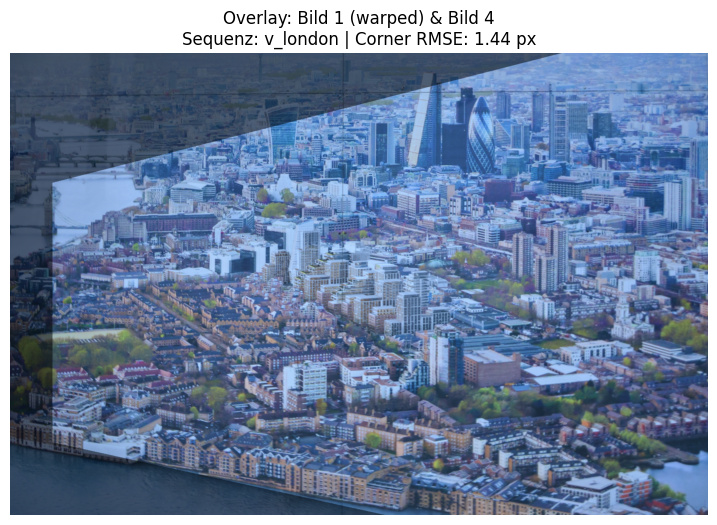


--- QUANTITATIVE ERGEBNISSE (Mittelwert über alle Sequenzen) ---
Bild 1 zu Bild 2 (Härterer Winkel) -> Durchschnittlicher RMSE: 0.92 Pixel
Bild 1 zu Bild 3 (Härterer Winkel) -> Durchschnittlicher RMSE: 3.03 Pixel
Bild 1 zu Bild 4 (Härterer Winkel) -> Durchschnittlicher RMSE: 42.66 Pixel
Bild 1 zu Bild 5 (Härterer Winkel) -> Durchschnittlicher RMSE: 45.61 Pixel
Bild 1 zu Bild 6 (Härterer Winkel) -> Durchschnittlicher RMSE: 85.13 Pixel


In [5]:
mean_errors = run_full_hpatches_evaluation("../CV-notebooks/hpatches-sequences-release/")

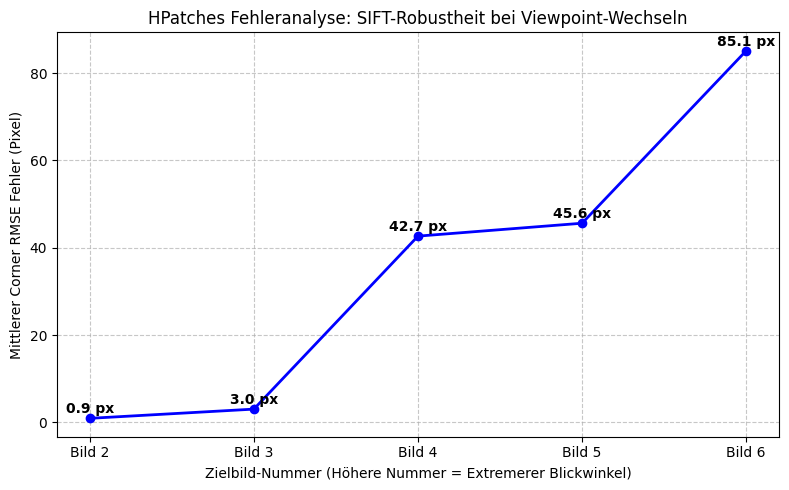

In [6]:
# Diagramm zeichnen
plt.figure(figsize=(8, 5))
image_stages = list(range(2, 7))
plt.plot(image_stages, mean_errors, marker="o", linestyle="-", color="b", linewidth=2)
plt.title("HPatches Fehleranalyse: SIFT-Robustheit bei Viewpoint-Wechseln")
plt.xlabel("Zielbild-Nummer (Höhere Nummer = Extremerer Blickwinkel)")
plt.ylabel("Mittlerer Corner RMSE Fehler (Pixel)")
plt.xticks(image_stages, [f"Bild {i}" for i in image_stages])
plt.grid(True, linestyle="--", alpha=0.7)

# Werte an den Punkten anzeigen
for x, y in zip(image_stages, mean_errors):
    if not np.isnan(y):
        plt.text(x, y + 0.5, f"{y:.1f} px", ha="center", va="bottom", fontsize=10, weight="bold")

plt.tight_layout()
plt.show()